# Pressure-gradient analysis notebook

This notebook extends your current workflow to compute the **pressure gradient** on the 2-D plane, find the **maximum pressure-gradient magnitude**, and visualize/compare it across schemes.

It does three main things:

1. Loads a CFD snapshot from your `step_*.csv`
2. Computes
   - $\partial p/\partial x$
   - $\partial p/\partial y$
   - $|\nabla p| = \sqrt{(\partial p/\partial x)^2 + (\partial p/\partial y)^2}$
3. Reports the maximum value and its location, then compares schemes


In [2]:

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
# Set specific sizes for axis labels and tick labels
plt.rcParams['axes.labelsize'] = 14   # Fontsize of the x and y axis labels
plt.rcParams['xtick.labelsize'] = 14  # Fontsize of the x tick labels
plt.rcParams['ytick.labelsize'] = 14  # Fontsize of the y tick labels



In [3]:

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
run_folder = Path("runs/2026-03-26_19-52-30_512x512_omp12")
schemes = ["FirstOrder", "WENO3", "WENO5", "TENO5"]

# Choose which scalar field to slice/plot
field_name = "p"      # "p", "rho", "u", "v", etc.

# Which step to load
step_index = -1       # -1 = last timestep

# Slice control:
# direction = "x"  -> plot field vs x at fixed y
# direction = "y"  -> plot field vs y at fixed x
direction = "x"

# Put either "center" or a number
slice_value = 0.0000048828125
# slice_value = "center"

# For quick one-file testing, you can point directly to a CSV:
# single_csv_override = Path("/mnt/data/step_1253.csv")
single_csv_override = None


## Helpers

In [4]:

def load_step_csv(file_path):
    """
    Load one CFD snapshot CSV and return:
        x_vals, y_vals, fields_dict, time
    where each field is shaped (ny, nx).

    Uses pivot_table instead of reshape so the grid assembly is more robust.
    """
    df = pd.read_csv(file_path, comment="#")

    x_vals = np.sort(df["x"].unique())
    y_vals = np.sort(df["y"].unique())

    field_columns = [c for c in df.columns if c not in ["x", "y"]]
    fields = {}

    for col in field_columns:
        grid = (
            df.pivot(index="y", columns="x", values=col)
              .sort_index(axis=0)
              .sort_index(axis=1)
        )
        fields[col] = grid.to_numpy()

    with open(file_path, "r") as f:
        first_line = f.readline().strip()
    time = float(first_line.split("=")[1])

    return x_vals, y_vals, fields, time


def get_step_file(scheme, step_index=-1):
    data_dir = run_folder / f"{scheme}_512x512_omp12" / "data"

    files = sorted(
        glob.glob(str(data_dir / "step_*.csv")),
        key=lambda f: int(Path(f).stem.split("_")[1])
    )

    if not files:
        raise FileNotFoundError(f"No step files found for {scheme} in {data_dir}")

    return files[step_index]


def nearest_index(array, value):
    return int(np.argmin(np.abs(array - value)))


def extract_slice(x, y, field, direction="x", slice_value="center"):
    """
    direction = "x": field vs x at fixed y
    direction = "y": field vs y at fixed x
    """
    if direction == "x":
        if slice_value == "center":
            j = len(y) // 2
        else:
            j = nearest_index(y, float(slice_value))

        coord = x
        values = field[j, :]
        actual_slice = y[j]
        axis_label = "x [mm]"
        slice_label = f"y = {actual_slice:.6e} m"

    elif direction == "y":
        if slice_value == "center":
            i = len(x) // 2
        else:
            i = nearest_index(x, float(slice_value))

        coord = y
        values = field[:, i]
        actual_slice = x[i]
        axis_label = "y [mm]"
        slice_label = f"x = {actual_slice:.6e} m"

    else:
        raise ValueError("direction must be 'x' or 'y'")

    return coord, values, actual_slice, axis_label, slice_label


def compute_gradient(x, y, field):
    """
    Compute spatial gradients for a field shaped (ny, nx).

    np.gradient returns derivatives in axis order:
      axis 0 -> y direction
      axis 1 -> x direction
    """
    dfield_dy, dfield_dx = np.gradient(field, y, x)
    grad_mag = np.hypot(dfield_dx, dfield_dy)
    return dfield_dx, dfield_dy, grad_mag


def get_max_gradient_info(x, y, grad_mag):
    """
    Return max gradient magnitude and its location.
    """
    flat_idx = np.argmax(grad_mag)
    j, i = np.unravel_index(flat_idx, grad_mag.shape)

    return {
        "max_grad": grad_mag[j, i],
        "x": x[i],
        "y": y[j],
        "i": i,
        "j": j
    }


## Load one case and compute pressure gradient

In [5]:

# Choose one scheme to inspect in detail
scheme_to_view = "FirstOrder"

if single_csv_override is not None:
    file_to_plot = single_csv_override
else:
    file_to_plot = get_step_file(scheme_to_view, step_index=step_index)

x, y, fields, time = load_step_csv(file_to_plot)

p = fields["p"]
dpdx, dpdy, gradp_mag = compute_gradient(x, y, p)
max_info = get_max_gradient_info(x, y, gradp_mag)

print(f"Loaded file: {file_to_plot}")
print(f"Simulation time: {time:.6e} s")
print(f"Pressure array shape: {p.shape}")
print(f"Max |grad p| = {max_info['max_grad']:.6e} Pa/m")
print(f"Location       = (x, y) = ({max_info['x']:.6e}, {max_info['y']:.6e}) m")
print(f"Grid indices    = (i, j) = ({max_info['i']}, {max_info['j']})")


Loaded file: runs/2026-03-26_19-52-30_512x512_omp12/FirstOrder_512x512_omp12/data/step_1931.csv
Simulation time: 2.000000e-06 s
Pressure array shape: (512, 512)
Max |grad p| = 1.133887e+09 Pa/m
Location       = (x, y) = (9.912109e-04, 8.837891e-04) m
Grid indices    = (i, j) = (101, 90)


## Plot pressure-gradient magnitude on the full 2-D plane

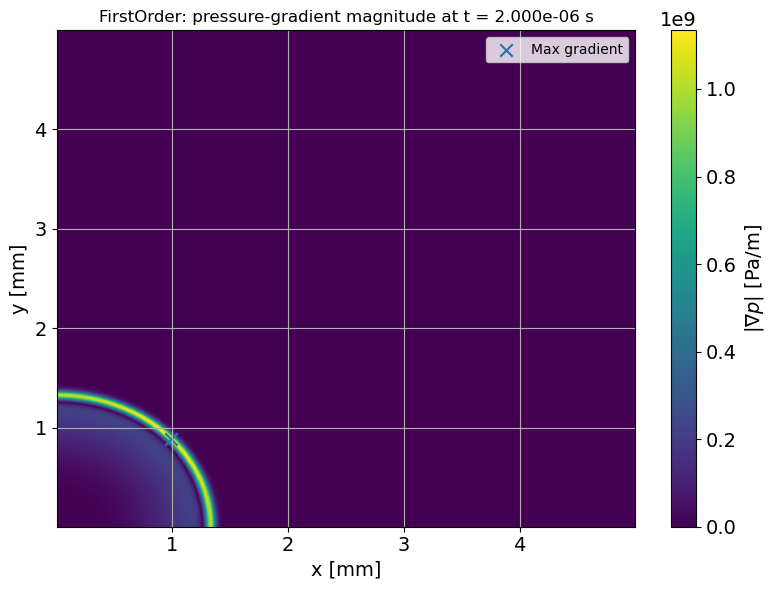

In [6]:

extent = [x.min()*1000, x.max()*1000, y.min()*1000, y.max()*1000]

plt.figure(figsize=(8, 6))
im = plt.imshow(
    gradp_mag,
    origin="lower",
    extent=extent,
    aspect="auto"
)
plt.colorbar(im, label=r"$|\nabla p|$ [Pa/m]")
plt.scatter(max_info["x"]*1000, max_info["y"]*1000, s=80, marker="x", label="Max gradient")
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"{scheme_to_view}: pressure-gradient magnitude at t = {time:.3e} s")
plt.legend()
plt.tight_layout()
plt.show()


## Compare the pressure slice across schemes

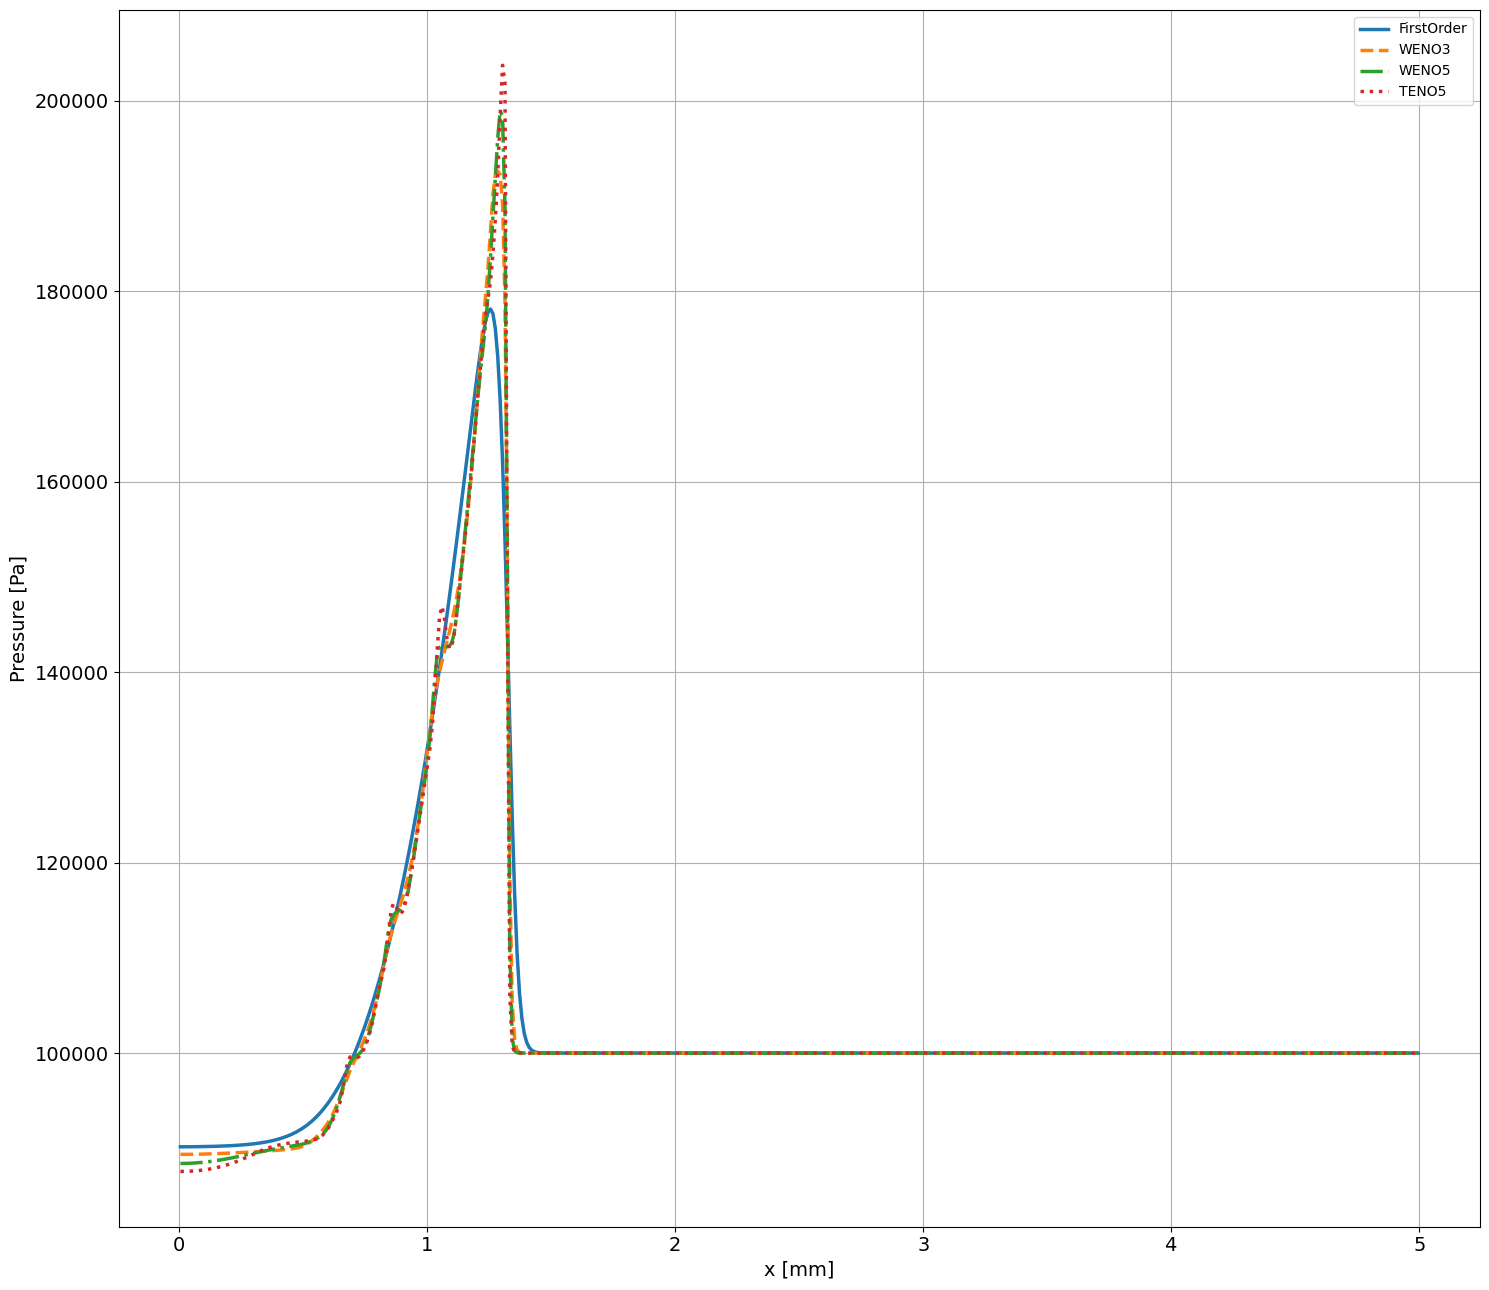

Requested slice value: 4.8828125e-06
Actual slice used: y = 4.882813e-06 m

Times used:
FirstOrder: 2.000000e-06 s
WENO3: 2.000000e-06 s
WENO5: 2.000000e-06 s
TENO5: 2.000000e-06 s


In [7]:

plt.figure(figsize=(15, 13))

times = {}
line_styles = ["-", "--", "-.", ":"]
linewidths = [2.5, 2.5, 2.5, 2.5]

for i, scheme in enumerate(schemes):
    if single_csv_override is not None and len(schemes) > 1:
        # If using a one-off uploaded CSV, only the first "scheme" can be shown meaningfully
        continue

    file_to_plot = get_step_file(scheme, step_index=step_index)
    x, y, fields, time = load_step_csv(file_to_plot)
    times[scheme] = time

    coord, values, actual_slice, axis_label, slice_label = extract_slice(
        x, y, fields[field_name],
        direction=direction,
        slice_value=slice_value
    )

    plt.plot(
        coord * 1000,
        values,
        linestyle=line_styles[i % len(line_styles)],
        linewidth=linewidths[i % len(linewidths)],
        label=scheme
    )

ylabel_map = {
    "p": "Pressure [Pa]",
    "rho": "Density [kg/m$^3$]",
    "u": "u velocity [m/s]",
    "v": "v velocity [m/s]",
    "E": "Energy",
    "rhou": "rho*u",
    "rhov": "rho*v",
    "H": "Enthalpy"
}

plt.xlabel(axis_label)
plt.ylabel(ylabel_map.get(field_name, field_name))
plt.legend()
plt.tight_layout()
plt.show()

print("Requested slice value:", slice_value)
print("Actual slice used:", slice_label)

print("\nTimes used:")
for scheme, t in times.items():
    print(f"{scheme}: {t:.6e} s")


## Compare gradient-magnitude slices across schemes

This is usually more useful than just plotting pressure when you want to identify where the shock or strongest compression is.

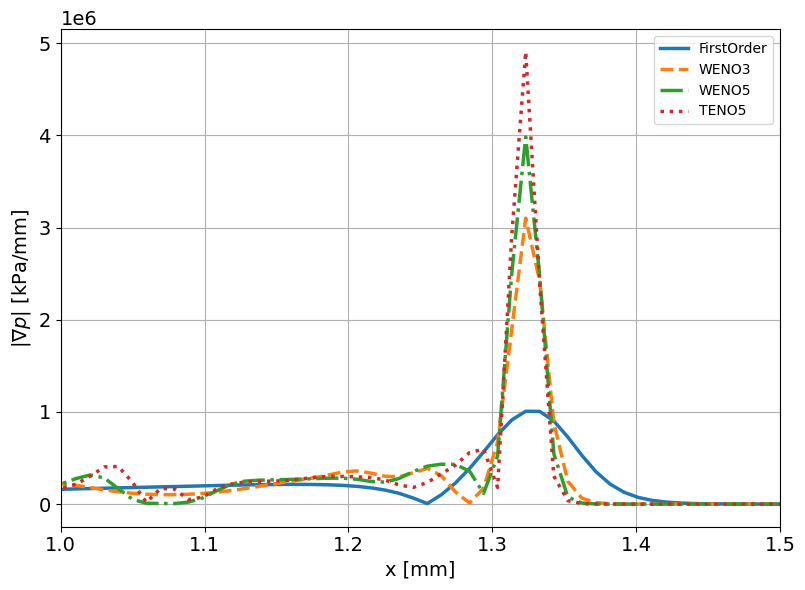

Requested slice value: 4.8828125e-06
Actual slice used: y = 4.882813e-06 m


In [8]:

plt.figure(figsize=(8, 6))

for i, scheme in enumerate(schemes):
    if single_csv_override is not None and len(schemes) > 1:
        continue

    file_to_plot = get_step_file(scheme, step_index=step_index)
    x, y, fields, time = load_step_csv(file_to_plot)

    dpdx, dpdy, gradp_mag = compute_gradient(x, y, fields["p"])

    coord, values, actual_slice, axis_label, slice_label = extract_slice(
        x, y, gradp_mag,
        direction=direction,
        slice_value=slice_value
    )

    plt.plot(
        coord * 1000,
        values /1000,
        linestyle=line_styles[i % len(line_styles)],
        linewidth=linewidths[i % len(linewidths)],
        label=scheme
    )

plt.xlabel(axis_label)
plt.ylabel(r"$|\nabla p|$ [kPa/mm]")
plt.legend()
plt.tight_layout()
plt.xlim(1,1.5)
#plt.title("Pressure Gradient Across X-Direction")
#plt.savefig(f"Figures/max_pressure_gradient.png", dpi = 300)
plt.show()

print("Requested slice value:", slice_value)
print("Actual slice used:", slice_label)


## Compute the max pressure gradient for every scheme

In [9]:

results = []

if single_csv_override is not None:
    x, y, fields, time = load_step_csv(single_csv_override)
    dpdx, dpdy, gradp_mag = compute_gradient(x, y, fields["p"])
    info = get_max_gradient_info(x, y, gradp_mag)
    results.append({
        "scheme": "uploaded_csv",
        "time_s": time,
        "max_grad_p_Pa_per_m": info["max_grad"],
        "x_m": info["x"],
        "y_m": info["y"],
        "i": info["i"],
        "j": info["j"]
    })
else:
    for scheme in schemes:
        file_to_plot = get_step_file(scheme, step_index=step_index)
        x, y, fields, time = load_step_csv(file_to_plot)

        dpdx, dpdy, gradp_mag = compute_gradient(x, y, fields["p"])
        info = get_max_gradient_info(x, y, gradp_mag)

        results.append({
            "scheme": scheme,
            "time_s": time,
            "max_grad_p_Pa_per_m": info["max_grad"],
            "x_m": info["x"],
            "y_m": info["y"],
            "i": info["i"],
            "j": info["j"]
        })

results_df = pd.DataFrame(results).sort_values("max_grad_p_Pa_per_m", ascending=False)
results_df


,scheme,time_s,max_grad_p_Pa_per_m,x_m,y_m,i,j
3,TENO5,0.000002,6.581395e+09,0.001001,0.000864,102,88
2,WENO5,0.000002,5.491596e+09,0.001001,0.000864,102,88
1,WENO3,0.000002,4.139848e+09,0.001001,0.000864,102,88
0,FirstOrder,0.000002,1.133887e+09,0.000991,0.000884,101,90


## Bar chart of max pressure gradient by scheme

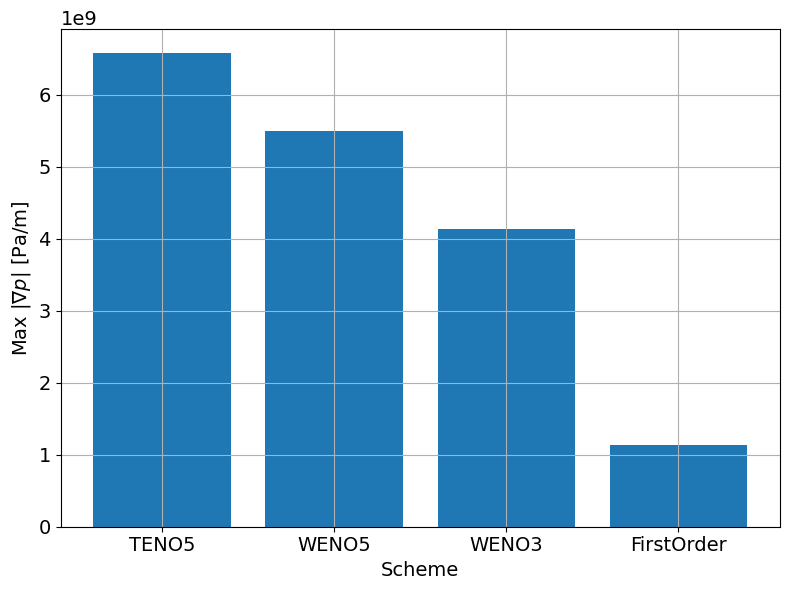

In [10]:

plt.figure(figsize=(8, 6))
plt.bar(results_df["scheme"], results_df["max_grad_p_Pa_per_m"])
plt.ylabel(r"Max $|\nabla p|$ [Pa/m]")
plt.xlabel("Scheme")
plt.tight_layout()
plt.show()


## Optional: inspect the exact row containing the maximum gradient

In [11]:

# Example for the currently loaded detailed-view case
j = max_info["j"]
i = max_info["i"]

print("p at max-grad point      :", p[j, i])
print("dp/dx at max-grad point  :", dpdx[j, i])
print("dp/dy at max-grad point  :", dpdy[j, i])
print("|grad p| at max-grad point:", gradp_mag[j, i])


p at max-grad point      : 139776.746899939
dp/dx at max-grad point  : -3347638806.5863132
dp/dy at max-grad point  : -2834266656.8722916
|grad p| at max-grad point: 4386314291.249621


## Notes

- `np.gradient(field, y, x)` uses the actual grid spacing, so this works even if your spacing changes.
- Since the field array is shaped `(ny, nx)`, the returned derivatives are:
  - first output: derivative in **y**
  - second output: derivative in **x**
- For shock detection, the **gradient magnitude** is usually the cleanest quantity:
  - large values of $|\nabla p|$ typically mark shocks or very sharp compressions.
- If you want a *signed* measure instead, you can also inspect `dpdx` or `dpdy` directly.

A common next step is to threshold `|\nabla p|` and track the shock position automatically.
